In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("diabetes.csv")
feature_cols = [c for c in df.columns if c != "Outcome"]

means = df[feature_cols].mean(numeric_only=True)
Xbin = pd.DataFrame({c: (df[c] <= means[c]) for c in feature_cols})

print("Means:")
display(means)
print("Binary table head (True = <= mean):")
display(Xbin.head())

Means:


Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
dtype: float64

Binary table head (True = <= mean):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,False,False,False,False,True,False,False,False
1,True,True,True,False,True,True,True,True
2,False,False,True,True,True,True,False,True
3,True,True,True,False,False,True,True,True
4,True,False,True,False,False,False,False,True


In [3]:
def contingency_2x2(a_event: pd.Series, b_event: pd.Series) -> tuple[int, int, int, int]:
    a_event = a_event.astype(bool)
    b_event = b_event.astype(bool)

    a = int((a_event & b_event).sum())
    b = int((a_event & ~b_event).sum())
    c = int((~a_event & b_event).sum())
    d = int((~a_event & ~b_event).sum())
    return a, b, c, d


def yule_q(a: int, b: int, c: int, d: int) -> float:
    denom = a * d + b * c
    return (a * d - b * c) / denom if denom else 0.0


def yule_y(a: int, b: int, c: int, d: int) -> float:
    ad = a * d
    bc = b * c
    denom = np.sqrt(ad) + np.sqrt(bc)
    return (np.sqrt(ad) - np.sqrt(bc)) / denom if denom else 0.0


def phi(a: int, b: int, c: int, d: int) -> float:
    denom = (a + b) * (c + d) * (a + c) * (b + d)
    return (a * d - b * c) / np.sqrt(denom) if denom else 0.0


def pearson_contingency_c(phi_value: float, n: int) -> float:
    chi2 = n * (phi_value ** 2)
    return np.sqrt(chi2 / (chi2 + n)) if (chi2 + n) else 0.0

In [4]:
col_i = "Glucose"
col_j = "Insulin"

A = Xbin[col_i]
B = Xbin[col_j]
a, b, c, d = contingency_2x2(A, B)

n = a + b + c + d
phi_val = phi(a, b, c, d)
Q = yule_q(a, b, c, d)
Y = yule_y(a, b, c, d)
C = pearson_contingency_c(phi_val, n)

print(f"Пара: i={col_i}, j={col_j}")
print("Таблица 2×2 (a,b,c,d):")

table = pd.DataFrame(
    [[a, b], [c, d]],
    index=["A (<= mean)", "not A"],
    columns=["B (<= mean)", "not B"],
)
display(table)

print("Коэффициенты:")
print(f"  r_B (=phi) = {phi_val:.6f}")
print(f"  Pearson contingency C = {C:.6f}")
print(f"  Yule association Q = {Q:.6f}")
print(f"  Yule colligation Y = {Y:.6f}")

Пара: i=Glucose, j=Insulin
Таблица 2×2 (a,b,c,d):


,B (<= mean),not B
A (<= mean),306,113
not A,173,176


Коэффициенты:
  r_B (=phi) = 0.241127
  Pearson contingency C = 0.234409
  Yule association Q = 0.467366
  Yule colligation Y = 0.248063


In [5]:
cols = feature_cols
n = len(df)

Q_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)
Y_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)
phi_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)  # r_B
C_mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        a, b, c, d = contingency_2x2(Xbin[i], Xbin[j])
        ph = phi(a, b, c, d)
        phi_mat.loc[i, j] = ph
        Q_mat.loc[i, j] = yule_q(a, b, c, d)
        Y_mat.loc[i, j] = yule_y(a, b, c, d)
        C_mat.loc[i, j] = pearson_contingency_c(ph, n)

print("Матрица r_B (phi):")
display(phi_mat.round(4))

phi_mat.to_csv("rb_phi_matrix.csv")
Q_mat.to_csv("yule_Q_matrix.csv")
Y_mat.to_csv("yule_Y_matrix.csv")
C_mat.to_csv("pearson_C_matrix.csv")

print("Saved: rb_phi_matrix.csv, yule_Q_matrix.csv, yule_Y_matrix.csv, pearson_C_matrix.csv")

Матрица r_B (phi):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.0000,0.1298,0.2309,-0.0567,-0.1105,0.0528,-0.0438,0.5458
Glucose,0.1298,1.0000,0.2098,0.0604,0.2411,0.1753,0.0535,0.2281
BloodPressure,0.2309,0.2098,1.0000,0.0619,-0.0127,0.1986,0.0062,0.3085
SkinThickness,-0.0567,0.0604,0.0619,1.0000,0.3997,0.3741,0.1119,-0.0303
Insulin,-0.1105,0.2411,-0.0127,0.3997,1.0000,0.1633,0.1657,-0.0754
BMI,0.0528,0.1753,0.1986,0.3741,0.1633,1.0000,0.0711,0.1061
DiabetesPedigreeFunction,-0.0438,0.0535,0.0062,0.1119,0.1657,0.0711,1.0000,-0.0051
Age,0.5458,0.2281,0.3085,-0.0303,-0.0754,0.1061,-0.0051,1.0000


Saved: rb_phi_matrix.csv, yule_Q_matrix.csv, yule_Y_matrix.csv, pearson_C_matrix.csv


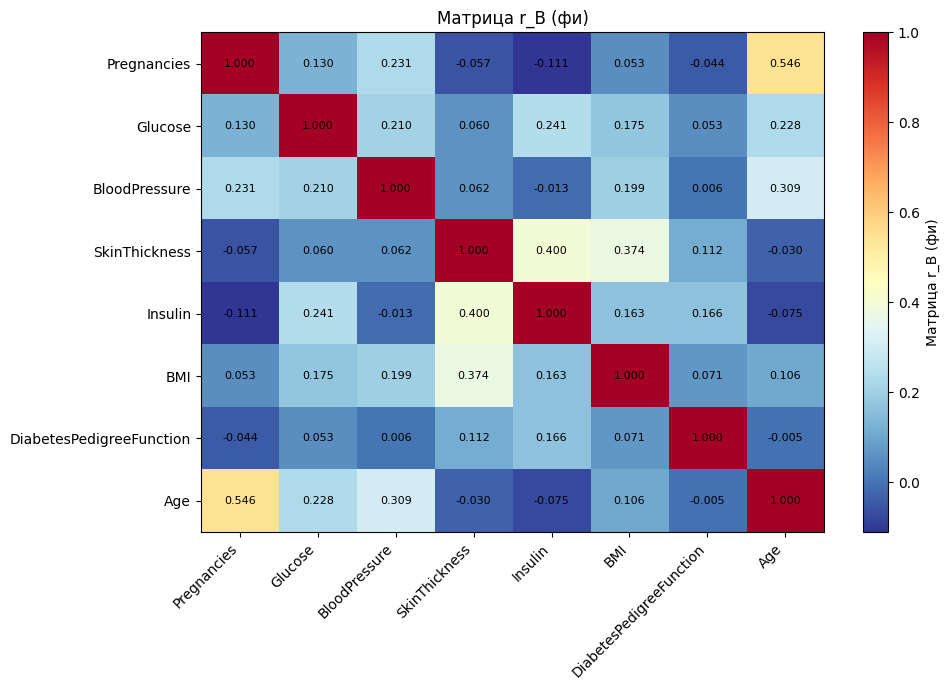

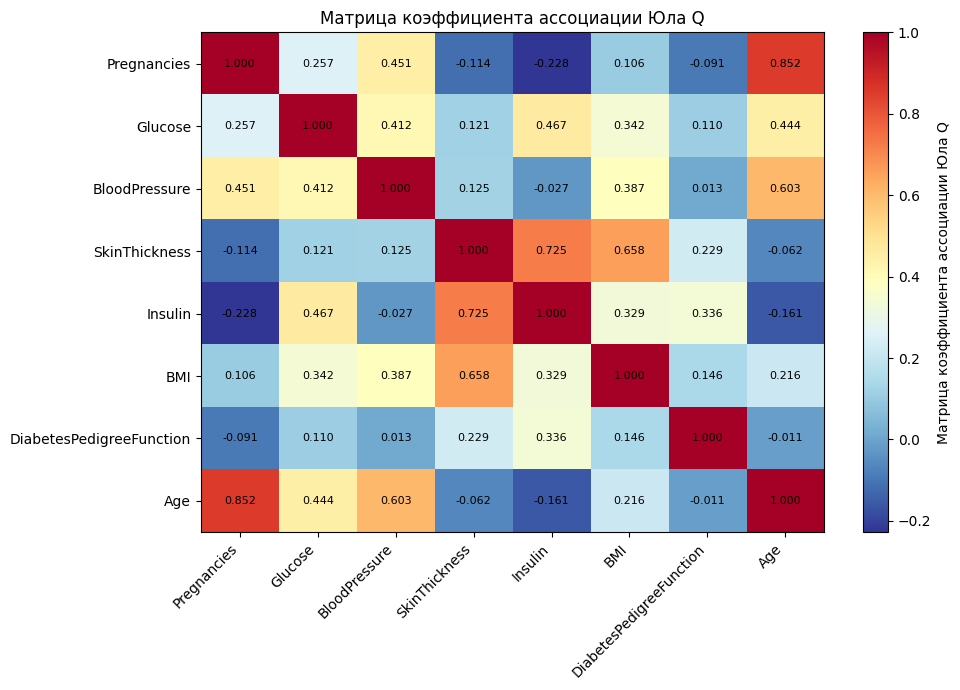

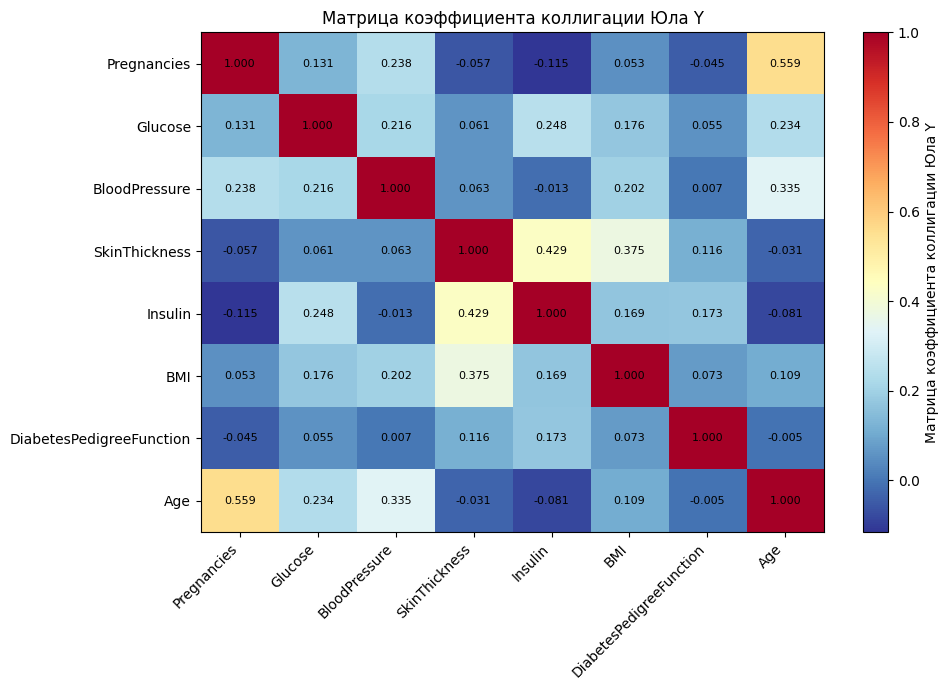

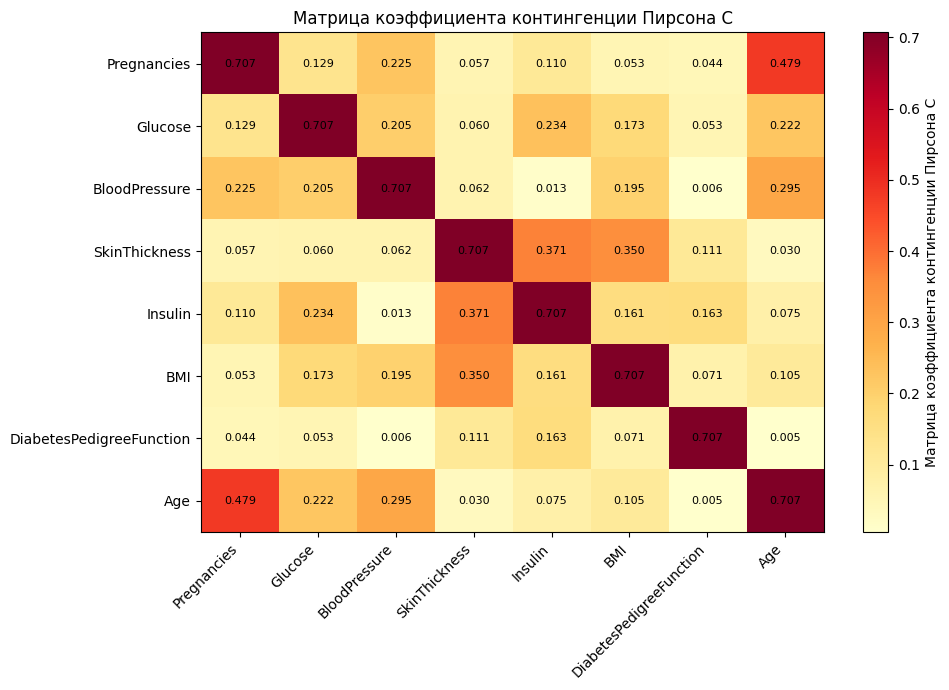

In [11]:
def heatmap(matrix: pd.DataFrame, title: str, cmap: str = "RdYlBu_r", fmt: str = "{:.3f}"):
    fig, ax = plt.subplots(figsize=(10, 7))
    M = matrix.values.astype(float)
    im = ax.imshow(M, cmap=cmap, aspect="auto")

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


heatmap(phi_mat, "Матрица r_B (фи)")
heatmap(Q_mat, "Матрица коэффициента ассоциации Юла Q")
heatmap(Y_mat, "Матрица коэффициента коллигации Юла Y")
heatmap(C_mat, "Матрица коэффициента контингенции Пирсона C", cmap="YlOrRd")

## Spearman (ранговая корреляция) — отдельная задача ранжирования

Этот блок **не использует бинаризацию**. Он строит таблицу коэффициентов Спирмена \(\rho_S\) по исходным числовым признакам как корреляцию их **рангов**.

In [7]:
import os
import numpy as np
import pandas as pd

os.makedirs("tables", exist_ok=True)

# Автономная загрузка
_df = pd.read_csv("diabetes.csv")
_feat = [c for c in _df.columns if c != "Outcome"]
X = _df[_feat].astype(float)

# 1) Матрица rho_S (Spearman) через ранги
spearman_rho = X.corr(method="spearman")

# 2) (Опционально) p-values, если доступен SciPy
spearman_p = None
try:
    from scipy.stats import spearmanr  # type: ignore

    rho, p = spearmanr(X.to_numpy(), axis=0)
    spearman_rho = pd.DataFrame(rho, index=_feat, columns=_feat)
    spearman_p = pd.DataFrame(p, index=_feat, columns=_feat)
except Exception as e:
    print("SciPy недоступен или spearmanr не сработал; p-values не рассчитаны.")
    print("Причина:", repr(e))

print("Spearman rho matrix (head):")
display(spearman_rho.head())

# Сохранение (CSV + LaTeX)
rho_csv = os.path.join("tables", "spearman_rho_matrix.csv")
spearman_rho.to_csv(rho_csv, encoding="utf-8-sig")

rho_tex = os.path.join("tables", "spearman_rho_matrix.tex")
spearman_rho.round(4).to_latex(rho_tex)

print("Saved:", rho_csv)
print("Saved:", rho_tex)

if spearman_p is not None:
    p_csv = os.path.join("tables", "spearman_p_matrix.csv")
    spearman_p.to_csv(p_csv, encoding="utf-8-sig")

    p_tex = os.path.join("tables", "spearman_p_matrix.tex")
    spearman_p.round(6).to_latex(p_tex)

    print("Saved:", p_csv)
    print("Saved:", p_tex)

# Быстрый рейтинг самых сильных связей по |rho|
abs_rho = spearman_rho.abs().copy()
np.fill_diagonal(abs_rho.values, np.nan)
rank = (
    abs_rho.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "i", "level_1": "j", 0: "abs_rho"})
)

# Убираем дубли пар (i,j) и (j,i)
rank["pair"] = rank.apply(lambda r: "::".join(sorted([r["i"], r["j"]])), axis=1)
rank = rank.drop_duplicates("pair").drop(columns=["pair"])

rank_path = os.path.join("tables", "spearman_abs_rho_ranking.csv")
rank.to_csv(rank_path, index=False, encoding="utf-8-sig")

print("Top-10 |rho| pairs:")
display(rank.head(10))
print("Saved:", rank_path)

Spearman rho matrix (head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.130734,0.185127,-0.085222,-0.126723,0.000132,-0.043242,0.607216
Glucose,0.130734,1.000000,0.235191,0.060022,0.213206,0.231141,0.091293,0.285045
BloodPressure,0.185127,0.235191,1.000000,0.126486,-0.006771,0.292870,0.030046,0.350895
SkinThickness,-0.085222,0.060022,0.126486,1.000000,0.541000,0.443615,0.180390,-0.066795
Insulin,-0.126723,0.213206,-0.006771,0.541000,1.000000,0.192726,0.221150,-0.114213


Saved: tables\spearman_rho_matrix.csv
Saved: tables\spearman_rho_matrix.tex
Saved: tables\spearman_p_matrix.csv
Saved: tables\spearman_p_matrix.tex
Top-10 |rho| pairs:


,i,j,abs_rho
0,Pregnancies,Age,0.607216
2,Insulin,SkinThickness,0.541000
4,SkinThickness,BMI,0.443615
6,Age,BloodPressure,0.350895
8,BloodPressure,BMI,0.292870
10,Age,Glucose,0.285045
12,BloodPressure,Glucose,0.235191
14,Glucose,BMI,0.231141
16,DiabetesPedigreeFunction,Insulin,0.221150
18,Glucose,Insulin,0.213206


Saved: tables\spearman_abs_rho_ranking.csv


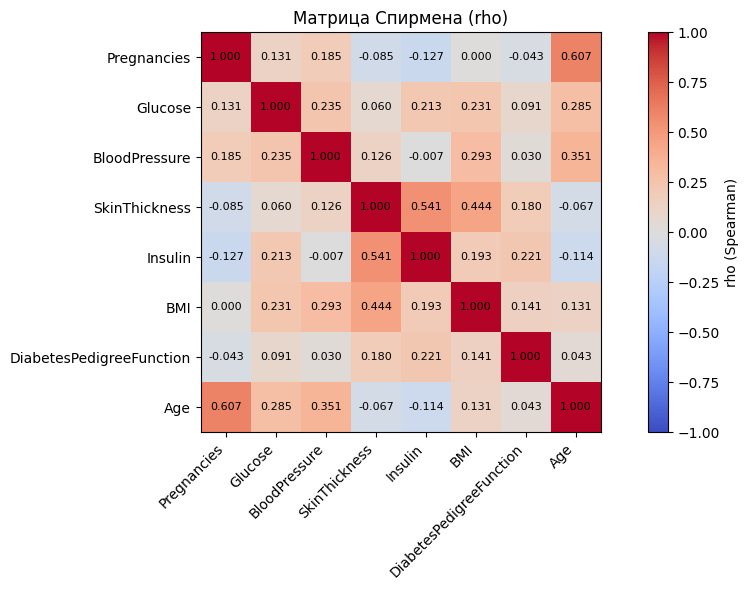

Saved: images\spearman_rho_heatmap.png


In [8]:
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

# Тепловая карта (как для r_B), но для Spearman rho
M = spearman_rho.copy()
labels = list(M.columns)
vals = M.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(vals, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Подписи значений
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.3f}", ha="center", va="center", fontsize=8, color="black")

ax.set_title("Матрица Спирмена (rho)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("rho (Spearman)")

fig.tight_layout()

out_png = os.path.join("images", "spearman_rho_heatmap.png")
fig.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

## Spearman с заданным числом ранговых уровней (K)

Если преподаватель требует «задать ранги вручную» (например, 5/10/100), это означает не классический Спирмен по исходным значениям, а **дискретизацию** каждого признака на K упорядоченных уровней (1..K), после чего считаем ранговую корреляцию уже по этим уровням.

Ниже реализован вариант через **квантили**: каждый столбец делится на K групп одинакового размера (примерно по 1/K выборки в каждой группе).

In [9]:
import numpy as np
import pandas as pd

# K — число уровней ("рангов"), которые вы хотите задать вручную
K_RANK_LEVELS = 10  # например 5, 10, 100


def quantile_levels(col: pd.Series, k: int) -> pd.Series:
    """Преобразует числовой столбец в уровни 1..k по квантилям (примерно равные группы)."""
    # qcut может "урезать" число бинов, если слишком много одинаковых значений
    levels = pd.qcut(col, q=k, labels=False, duplicates="drop")
    # levels в [0..k'-1], делаем [1..k']
    return (levels.astype(int) + 1).astype(int)


X_levels = pd.DataFrame({c: quantile_levels(X[c], K_RANK_LEVELS) for c in _feat})

# Реально получившееся число уровней может быть < K_RANK_LEVELS из-за ties
actual_levels = {c: int(X_levels[c].nunique()) for c in _feat}
print("Задано K =", K_RANK_LEVELS)
print("Фактически уровней по столбцам (из-за повторов может быть меньше):")
display(pd.Series(actual_levels).to_frame("n_levels"))

# Матрица "Spearman по уровням" (по сути связь между вашими заданными рангами)
spearman_rho_k = X_levels.corr(method="spearman")

print("Spearman rho по дискретным уровням (head):")
display(spearman_rho_k.head())

# Сохранение
out_rho_csv = f"tables/spearman_rho_levels_k{K_RANK_LEVELS}.csv"
out_rho_tex = f"tables/spearman_rho_levels_k{K_RANK_LEVELS}.tex"

spearman_rho_k.to_csv(out_rho_csv, encoding="utf-8-sig")
spearman_rho_k.round(4).to_latex(out_rho_tex)

print("Saved:", out_rho_csv)
print("Saved:", out_rho_tex)

# Рейтинг по |rho| для заданных уровней
abs_rho_k = spearman_rho_k.abs().copy()
np.fill_diagonal(abs_rho_k.values, np.nan)
rank_k = (
    abs_rho_k.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "i", "level_1": "j", 0: "abs_rho"})
)
rank_k["pair"] = rank_k.apply(lambda r: "::".join(sorted([r["i"], r["j"]])), axis=1)
rank_k = rank_k.drop_duplicates("pair").drop(columns=["pair"])

out_rank_csv = f"tables/spearman_abs_rho_levels_k{K_RANK_LEVELS}_ranking.csv"
rank_k.to_csv(out_rank_csv, index=False, encoding="utf-8-sig")

print("Top-10 |rho| pairs (уровни K):")
display(rank_k.head(10))
print("Saved:", out_rank_csv)

Задано K = 10
Фактически уровней по столбцам (из-за повторов может быть меньше):


,n_levels
Pregnancies,8
Glucose,10
BloodPressure,10
SkinThickness,8
Insulin,6
BMI,10
DiabetesPedigreeFunction,10
Age,10


Spearman rho по дискретным уровням (head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.143466,0.197345,-0.096825,-0.137003,0.014244,-0.042403,0.611701
Glucose,0.143466,1.000000,0.233818,0.068809,0.215205,0.233735,0.083916,0.285458
BloodPressure,0.197345,0.233818,1.000000,0.114223,-0.015407,0.282666,0.023442,0.349980
SkinThickness,-0.096825,0.068809,0.114223,1.000000,0.531021,0.437342,0.171838,-0.066855
Insulin,-0.137003,0.215205,-0.015407,0.531021,1.000000,0.190589,0.217507,-0.101524


Saved: tables/spearman_rho_levels_k10.csv
Saved: tables/spearman_rho_levels_k10.tex
Top-10 |rho| pairs (уровни K):


,i,j,abs_rho
0,Pregnancies,Age,0.611701
2,SkinThickness,Insulin,0.531021
4,SkinThickness,BMI,0.437342
6,Age,BloodPressure,0.349980
8,Glucose,Age,0.285458
10,BMI,BloodPressure,0.282666
12,Glucose,BloodPressure,0.233818
14,Glucose,BMI,0.233735
16,DiabetesPedigreeFunction,Insulin,0.217507
18,Insulin,Glucose,0.215205


Saved: tables/spearman_abs_rho_levels_k10_ranking.csv


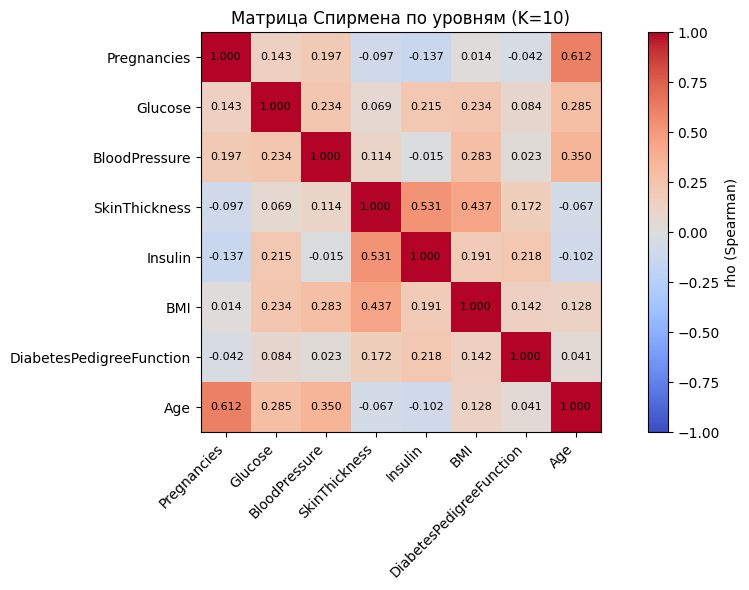

Saved: images\spearman_rho_levels_k10_heatmap.png


In [10]:
import matplotlib.pyplot as plt

# Heatmap для Spearman по дискретным уровням (K)
M_k = spearman_rho_k.copy()
labels_k = list(M_k.columns)
vals_k = M_k.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(vals_k, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(labels_k)))
ax.set_yticks(np.arange(len(labels_k)))
ax.set_xticklabels(labels_k, rotation=45, ha="right")
ax.set_yticklabels(labels_k)

for i in range(vals_k.shape[0]):
    for j in range(vals_k.shape[1]):
        ax.text(j, i, f"{vals_k[i, j]:.3f}", ha="center", va="center", fontsize=8, color="black")

ax.set_title(f"Матрица Спирмена по уровням (K={K_RANK_LEVELS})")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("rho (Spearman)")

fig.tight_layout()

out_png_k = os.path.join("images", f"spearman_rho_levels_k{K_RANK_LEVELS}_heatmap.png")
fig.savefig(out_png_k, dpi=200)
plt.show()

print("Saved:", out_png_k)